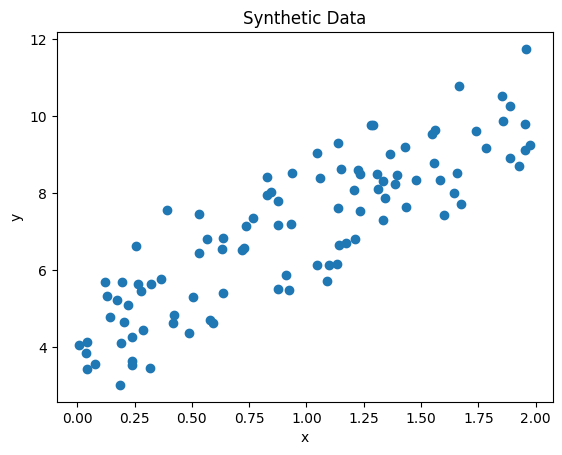

In [3]:
#Dataset 1 (Linear Data)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

plt.scatter(X, y)
plt.title("Synthetic Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

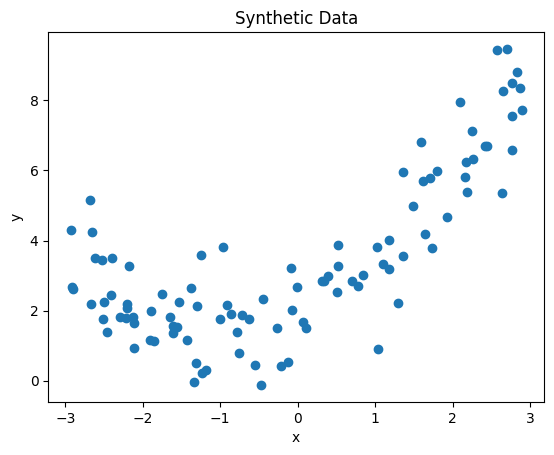

In [4]:
#Dataset 2 (Nonlinear Data)

X_nl = 6 * np.random.rand(m, 1) - 3
y_nl = 0.5 * X_nl**2 + X_nl + 2 + np.random.randn(m, 1)

plt.scatter(X_nl, y_nl)
plt.title("Synthetic Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [5]:
# Q1(a)

X_b = add_dummy_feature(X)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("Theta values:\n", theta_best)

Theta values:
 [[4.22215108]
 [2.96846751]]


The best parameters found using the normal equation are θ0 = 2.96846751 and θ1 = 4.22215108

Predictions:
 [[ 4.22215108]
 [10.1590861 ]]


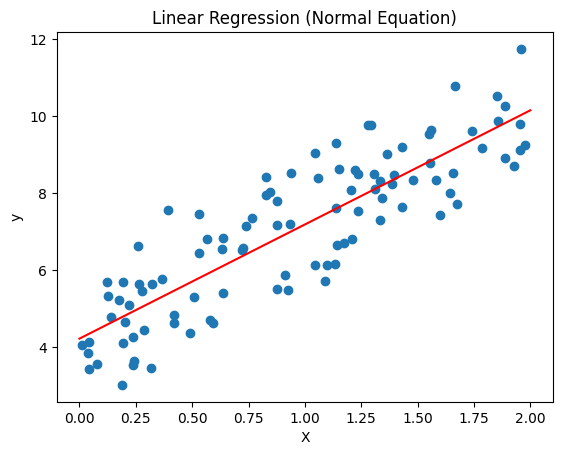

In [6]:
# Q1(b)

X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)

y_pred = X_new_b @ theta_best

print("Predictions:\n", y_pred)

plt.scatter(X, y)
plt.plot(X_new, y_pred, "r-")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression (Normal Equation)")
plt.show()

The predicted values for the new input points are:

* - For x = 0 → y ≈ 4.22  
* - For x = 2 → y ≈ 10.16  

These predictions are obtained using the linear regression model computed with the Normal Equation.

In [7]:
# Q2(a)

np.random.seed(0)
theta = np.random.randn(2, 1)

eta = 0.1
n_epochs = 1000
m = len(X_b)

for epoch in range(n_epochs):
    gradients = (2/m) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print("Theta (Gradient Descent):\n", theta)

Theta (Gradient Descent):
 [[4.22215108]
 [2.96846751]]


The parameters obtained using Gradient Descent are:

* - θ₀ ≈ 4.22  
* - θ₁ ≈ 2.97  

These values are very similar to the parameters obtained using the Normal Equation.

The reason is that both methods aim to minimize the same cost function, which is the Mean Squared Error (MSE). The Normal Equation computes the exact solution analytically, while Gradient Descent iteratively approaches the optimal solution. Since the learning rate is appropriate and the number of epochs is sufficient, Gradient Descent successfully converges to a solution very close to the optimal parameters.

In [8]:
# Q2(b)

np.random.seed(0)
theta = np.random.randn(2, 1)

eta = 0.01
n_epochs = 1000
m = len(X_b)

for epoch in range(n_epochs):
    gradients = (2/m) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print("Theta (lr=0.01):\n", theta)

Theta (lr=0.01):
 [[4.21816298]
 [2.97200627]]


Smaller learning rate slows convergence.

In [9]:
# Q2(c)

np.random.seed(0)
theta = np.random.randn(2, 1)

eta = 0.5
n_epochs = 1000
m = len(X_b)

for epoch in range(n_epochs):
    gradients = (2/m) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print("Theta (lr=0.5):\n", theta)

Theta (lr=0.5):
 [[-9.75653793e+27]
 [-1.09953918e+28]]


With a learning rate of 0.5, the algorithm was not able to obtain the same parameters as in question 2(a).

The values diverged and became extremely large, indicating that the model did not converge. This happens because the learning rate is too high, causing the updates to overshoot the optimal solution at each step. As a result, instead of approaching the minimum, the algorithm moves further away and becomes unstable.

Therefore, a large learning rate leads to divergence rather than convergence.

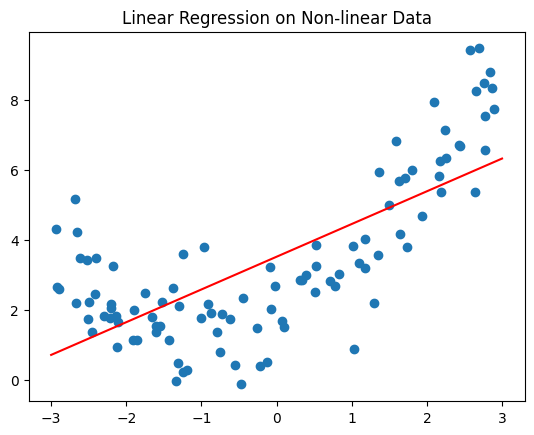

In [10]:
# Q3(a)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_nl, y_nl)

X_new = np.linspace(-3, 3, 100).reshape(100, 1)

plt.scatter(X_nl, y_nl)
plt.plot(X_new, model.predict(X_new), "r-")
plt.title("Linear Regression on Non-linear Data")
plt.show()

The linear regression model underfits the training data.

This is because the data has a non-linear (curved) pattern, while the linear regression model can only fit a straight line. As a result, the model is too simple to capture the underlying relationship in the data, leading to poor performance.

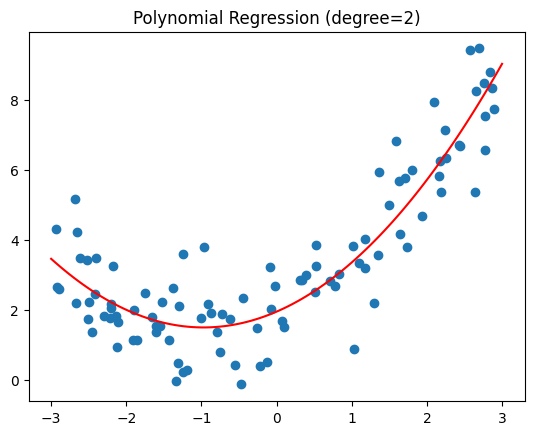

In [11]:
# Q3(b)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

model.fit(X_nl, y_nl)

X_new = np.linspace(-3, 3, 100).reshape(100, 1)

plt.scatter(X_nl, y_nl)
plt.plot(X_new, model.predict(X_new), "r-")
plt.title("Polynomial Regression (degree=2)")
plt.show()

The polynomial regression model (degree = 2) fits the training data well.

The model is flexible enough to capture the curved (non-linear) pattern in the data, unlike linear regression. It neither underfits nor overfits, and provides a good balance between bias and variance.

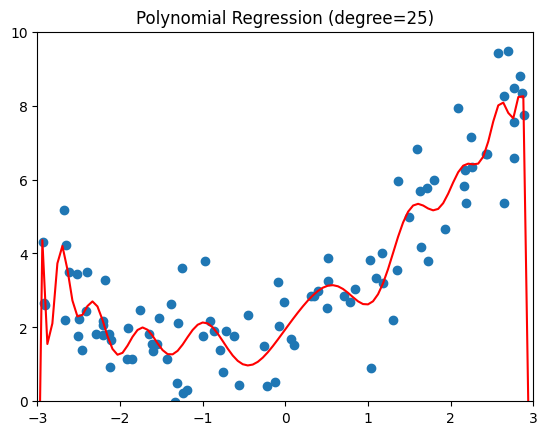

In [12]:
# Q3(c)

model = make_pipeline(
    PolynomialFeatures(degree=25, include_bias=False),
    LinearRegression()
)

model.fit(X_nl, y_nl)

X_new = np.linspace(-3, 3, 100).reshape(100, 1)

plt.scatter(X_nl, y_nl)
plt.plot(X_new, model.predict(X_new), "r-")
plt.axis([-3, 3, 0, 10])
plt.title("Polynomial Regression (degree=25)")
plt.show()

The polynomial regression model with degree 25 overfits the training data.

The model is too flexible and captures not only the underlying pattern but also the noise in the data. This results in a highly oscillating curve that does not generalize well.

Increasing the degree of the polynomial increases the variance of the model. A higher degree makes the model more sensitive to small changes in the training data, leading to overfitting.

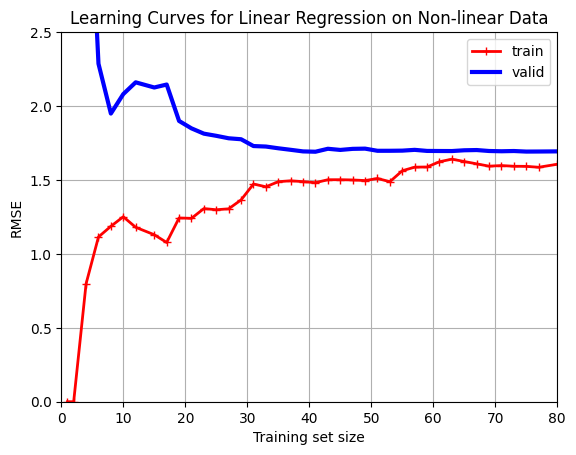

In [16]:
# Q4
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X_nl, y_nl,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error"
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curves for Linear Regression on Non-linear Data")
plt.grid(True)
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

The learning curve represents an underfitting model.

Both the training error and validation error reach a plateau and remain relatively close to each other at a fairly high level. This indicates that the linear regression model is too simple to capture the underlying non-linear pattern in the data.

Therefore, the model has high bias and does not fit the training set well.